In [174]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
import networkx as ntx
from scipy.integrate import solve_ivp
from scipy import signal
from utils.lmis_ts import *
import utils.levants as levants
import copy

rng = np.random.default_rng()

In [ ]:
# simulation time
time = 20
eta = 1
eps = 1e-9
x0 = np.array([0.5, 0.88, -0.25, 1, 0, 0, 0, 0])
x0_levants = np.zeros(15)

x0 = np.concat([x0, x0_levants], axis=0)

# normal cases
z_interval = [
    [0.2, 1],
    [.1667, 0.5],
    [-1, 1],
    [-4*math.pi, 4*math.pi]
]
zeta_interval = [
    [-2*math.pi, 2*math.pi]
]

# hyperplanes
a = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, -1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, -1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, -1],
])
b = 4*math.pi * np.ones(shape=(4*2, 1)) # limits of set D
bR = b/2.0 # limits of set R

In [176]:
# generate combinations for multi-index -> j, k \in \mathbb{I}_{n_z} and l \in \mathbb{I}_{n_zeta}
n_z = len(z_interval)
n_zeta = len(zeta_interval)

interval_size = 2 # Just to make this information explict

# amount_perm = 2*n_z + n_zeta
# _, jkl_perm = permn(np.arange(interval_size), amount_perm) # TODO: handle n_zeta = 0

j_perms, _ = permn(np.arange(interval_size), n_z)
k_perms, _ = permn(np.arange(interval_size), n_z)
l_perms, _ = permn(np.arange(interval_size), n_zeta)

In [177]:
### This functions must be changed for different systems
# Politopic representation
def A_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 1, 0, 1 + z[0]],
        [0, 2*z[1]*z[2]*z[3], 0, 2*z[1]*z[2]*zeta[0]],
    ])

def C_ijl(z: list[np.ndarray], zeta: list[np.ndarray], **kwargs) -> np.ndarray:
    return np.array([
        [1, 0, 0, 0],
        [0, 0, 1, 0],
    ])

theta_x1 = lambda x1: 3 + 2*math.sin(x1)

# alpha = [x1, x4_hat]
z_alpha = lambda alpha: np.array([
    [1/theta_x1(alpha[0, 0])],
    [1/(1 + theta_x1(alpha[0, 0]))],
    [math.cos(alpha[0, 0])],
    [alpha[1, 0]]
])

In [178]:
A_cell = []
C_cell = []

for j_p in j_perms:
    for l_p in l_perms:
        jl_perm = np.concat([j_p, l_p])

        A_ind = bin_from_perm(jl_perm)
        C_ind = A_ind

        z = []
        for j in range(n_z):
            z.append(z_interval[j][jl_perm[j]])
        
        zeta = []
        for j in range(n_zeta):
            zeta.append(zeta_interval[j][jl_perm[n_z + j]])
        A_cell.append(A_ijl(z, zeta))
        C_cell.append(C_ijl(z, zeta))

In [179]:
j_perms_plus = perm_plus(j_perms)
k_perms_plus = perm_plus(k_perms)

In [180]:
# i can move this functions to a politopic representation utils file

w0_alpha = lambda j, z: ((z_interval[j][1] - z[j]) / (z_interval[j][1] - z_interval[j][0]))
w1_alpha = lambda j, z: 1 - w0_alpha(j, z)

w_alpha = lambda j, z: [w0_alpha(j, z), w1_alpha(j, z)]

def phi_z(F: np.ndarray, z: np.ndarray, b: np.ndarray):
    '''
        ### The parameters are given from the expressions and are used to generate Lmis for Theorem 1 of Coutinho et al.
        R = { x \in RR^n : F@x <= b} \\
        phi(z) = min{ b.T@w: F.T@w = z, w \in RR^f >= 0 }
    '''

    w = cp.Variable((b.shape[0], 1))
    constrains = []

    constrains += [ w >= 0]
    
    constrains += [ F.T@w == z ]

    prob = cp.Problem(cp.Minimize(b.T@w), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

def W_ind(z: np.ndarray[float], J_perm_i) -> float:
    '''
        alpha = [alpha_1, ..., alpha_N}], alpha_1 = [alpha_11, ..., alpha_1{n_{alpha_1}}]` \\
        perm = multiindex permutations \\
        n_prods = number of products
    '''
    
    prod = 1
    for k in range(len(z)): # n_alpha_i
        prod *= w_alpha(k, z)[J_perm_i[k]]
    
    return prod

<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
C:\Users\luiza\AppData\Local\Temp\ipykernel_19984\3834517831.py:9: SyntaxWarning: invalid escape sequence '\i'
  '''


In [181]:
### LMIS

nx = A_cell[0].shape[0]
ny = C_cell[0].shape[0]

P = cp.Variable((nx, nx), symmetric=True)

L_till_cell = []
for perm in k_perms: #k_plus_perms_set: # k_perms_plus as a test instead of k_perms
    L_till = cp.Variable((nx, ny))
    L_till_cell.append(L_till)

constrains = []
constrains += [P >> eps]

# fixing upsilon
for l in l_perms:

    for m_index in j_perms_plus:
        for n_index in k_perms_plus:

            m_perms = multi_index_permutation(copy.deepcopy(m_index))
            n_perms = multi_index_permutation(copy.deepcopy(n_index))

            Upsilon_mnk_sum = 0
            for m_perm in m_perms:
                for n_perm in n_perms:
                    jl_perm = np.concat([m_perm, l])
                    
                    A_ind = bin_from_perm(copy.deepcopy(jl_perm))
                    L_ind = bin_from_perm(copy.deepcopy(n_perm))
                    C_ind = A_ind

                    M = P@A_cell[A_ind] - L_till_cell[L_ind]@C_cell[C_ind] + eta*P
                    Upsilon_mnk_sum += M + M.T
            
            constrains += [Upsilon_mnk_sum << -eps]

for j in range(a.T.shape[0]):
    # a.T@x <= b
    aj = np.expand_dims(a.T[j], axis=1)
    phi = phi_z(a.T, aj, bR)
    sj = 1/(b[j] - phi) * aj

    M = cp.bmat([
        [np.eye(1), sj.T],
        [sj       , P],
    ])
    constrains += [ M >> 0 ]

prob = cp.Problem(cp.Minimize(cp.trace(P)), constraints=constrains)
result = prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 17 10:20:40 PM: Your problem has 144 variables, 1016 constraints, and 0 parameters.
(CVXPY) Feb 17 10:20:40 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 17 10:20:40 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 17 10:20:40 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 17 10:20:40 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 17 10:20:40 PM: Compiling problem (target solver=MOSEK).

In [182]:
is_positive_defined = 'positive definite' if all(np.linalg.eig(P.value).eigenvalues > 0) else 'NOT positive defined'
print(f'P = \n{P.value}')
print(f"The solution is \'{prob.status}\', with Trace(P) = {result:.2f} and P is {is_positive_defined}")

P = 
[[ 1.5355337  -0.36010637  0.00778469  0.01651928]
 [-0.36010637  0.11429281 -0.10588834  0.00511066]
 [ 0.00778469 -0.10588834  2.40316466 -0.19856881]
 [ 0.01651928  0.00511066 -0.19856881  0.04193525]]
The solution is 'optimal', with Trace(P) = 4.09 and P is positive definite


In [183]:
L_cell = []

P_inv = np.linalg.inv(P.value)

for k in k_perms:
    L_ind = bin_from_perm(copy.deepcopy(k))
    L_cell.append(P_inv@(L_till_cell[L_ind]).value)

In [184]:
vec = np.array([math.pi, 4*math.pi, 4*math.pi, 4*math.pi, 0])
np.linalg.norm(vec)

np.float64(21.991148575128552)

In [185]:
# simulação
def f_x(x):
    return np.array([
        [x[1, 0]],
        [-x[1, 0]*theta_x1(x[0, 0]) - x[3, 0]],
        [x[3, 0]],  
        [-x[2, 0]],
    ]).reshape(4, 1)

def g_x(x: np.ndarray) -> np.ndarray[float]:
    return np.array([
        [0, 0],
        [theta_x1(x[0, 0]), 0],
        [1, 0],
        [0, 1],
    ])

def d_x(t: float) -> np.ndarray[float]:
    return np.array([
        [.5*signal.sawtooth(4*math.pi*0.0795774*t, width=0)],
        [signal.square(2*np.pi*0.0795774*t + math.pi)]
    ]).reshape(2, 1)

def h_x(x):
    return np.array([
        [x[0]],
        [x[2]],
    ]).reshape(2, 1)

def Gamma_inv(x):
    return np.array([
        [1/theta_x1(x[0, 0]), 0],
        [0, 1/-(1 + theta_x1(x[0, 0]))]
    ])

def Q_x(x: np.ndarray):
    return np.array([
        [0, 0],
        [1, 0],
        [1/theta_x1(x[0, 0]), 0],
        [0, -1/(1 + theta_x1(x[0, 0]))],
    ])

def Psi_x(x):
    return np.array([
        [-x[1, 0]*theta_x1(x[0, 0]) - x[3, 0]],
        [(1 + theta_x1(x[0, 0]))*x[2, 0] - 2*math.cos(x[0, 0])*x[1, 0]*x[3, 0]],
    ]).reshape(2, 1)

def dot_Y_levants(y: np.ndarray[float], Y_levants: np.ndarray[float]) -> np.ndarray[float]:
    # returns the \dot{Y}_levants

    # Prof. Coutinho gains -> lambda=0.5*[28;25;20;15;10];
    lambda_y1     = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y2     = 0.5*np.array([28, 25, 20, 15, 10])
    lambda_y2till = 0.5*np.array([28, 25, 20, 15, 10])

    n_y1     = lambda_y1.shape[0]
    n_y2     = lambda_y2.shape[0]
    n_y2till = lambda_y2till.shape[0]

    id_y1 = 0
    id_y2 = id_y1 + n_y1
    id_y2till = id_y2 + n_y2

    z_y1     = Y_levants[id_y1:n_y1]
    z_y2     = Y_levants[id_y2:id_y2+n_y2]
    z_y2till = Y_levants[id_y2till:id_y2till+n_y2till]

    y1 = y[0]
    y2 = y[1]
    y2till = z_y1[2] + theta_x1(y1)*(z_y1[1] - z_y2[1])

    dot_y1     = levants.differentiator(y1, z_y1, lambda_y1)
    dot_y2     = levants.differentiator(y2, z_y2, lambda_y2)
    dot_y2till = levants.differentiator(y2till, z_y2till, lambda_y2till)

    return np.concat([dot_y1, dot_y2, dot_y2till], axis=0)

def L_alpha(z: np.ndarray, perms: np.ndarray, L_cell: list[np.ndarray]):
    L = 0

    # W_id_sum = 0
    for i in range(len(perms)):
        # W_id_sum += W_ind(z, perms[i])
        L += W_ind(z, perms[i])*L_cell[i]

    # print(f"w_ind_sum = {W_id_sum}")
    return L

def model(t: float, xx: np.ndarray[float], dist_t: list, dist_d: list, dist_d_hat: list):
    print(f"t={t}s")
   
    nx = 4
    xdot = np.zeros(shape=xx.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # [0:4) -> system states
    # [4:8) -> observer states
    # [8:end] -> levants differentiator
    id_x = 0
    id_x_hat = id_x + nx
    id_Y_levants = id_x_hat + nx

    x = xx[id_x:id_x+nx].reshape(4, 1)
    x_hat = xx[id_x_hat:id_x_hat+nx].reshape(4, 1)
    Y_levants = xx[id_Y_levants:]

    # disturbance related
    g = g_x(x)
    d = d_x(t)
    
    # System simulation
    xdot[id_x:id_x+nx] = f_x(x) + g@d

    # inputs to estimator
    y = h_x(x)
    y_hat = h_x(x_hat)
    alpha = np.array([x[0], x_hat[3]]) # try this
    z = z_alpha(alpha)
    Q = Q_x(x_hat)
    Psi = Psi_x(x_hat)
    
    # levants differentiator output vector
    Y = np.array([
        [Y_levants[2]],
        [Y_levants[11]],
    ]).reshape(2, 1)

    # estimator gain
    L = L_alpha(z, k_perms, L_cell)
    
    # Estimatior simulation
    xdot[id_x_hat:id_x_hat+nx] = f_x(x_hat) + Q@(Y - Psi) + L@(y - y_hat)

    # levants differentiator update
    dot_Y = dot_Y_levants(y, Y_levants)
    xdot[id_Y_levants:] = dot_Y

    # disturbance estimatior
    d_hat = Gamma_inv(x_hat)@(Y - Psi)

    # disturbance value and estimatior storage
    dist_t.append(t)
    dist_d.append(d)
    dist_d_hat.append(d_hat)

    return xdot.flatten()

In [186]:
sim_time = (0, time)
dist_t = []
dist_d = []
dist_d_hat = []

result = solve_ivp(model, sim_time, x0, args=(dist_t, dist_d, dist_d_hat))  # BDF or LSODA
t = result.t

x = result.y

t=0.0s
t=4.709394996187837e-08s
t=9.418789992375675e-07s
t=1.4128184988563512e-06s
t=3.76751599695027e-06s
t=4.1861288855003e-06s
t=4.709394996187837e-06s
t=4.709394996187837e-06s
t=6.507647212656434e-06s
t=7.406773320890733e-06s
t=1.1902403862062225e-05s
t=1.2701627069381601e-05s
t=1.3700656078530822e-05s
t=1.3700656078530822e-05s
t=2.1226644536055627e-05s
t=2.498963876481803e-05s
t=4.3804609908630046e-05s
t=4.7149493667529956e-05s
t=5.1330598366154854e-05s
t=5.1330598366154854e-05s
t=7.344815001955936e-05s
t=8.450692584626162e-05s
t=0.0001398008049797729s
t=0.00014963082793684158s
t=0.0001619183566331774s
t=0.0001619183566331774s
t=0.00022853220095181773s
t=0.00026183912311113786s
t=0.0004283737339077387s
t=0.00045797988693824546s
t=0.000494987578226379s
t=0.000494987578226379s
t=0.0006936575168067687s
t=0.0007929924860969635s
t=0.0012896673325479377s
t=0.001377965083028111s
t=0.0014883372711283274s
t=0.0014883372711283274s
t=0.0020752198382366633s
t=0.002368661121790831s
t=0.0038358

C:\Users\luiza\AppData\Local\Temp\ipykernel_19984\826731017.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  theta_x1 = lambda x1: 3 + 2*math.sin(x1)



t=1.212525930016637s
t=1.2126879029374917s
t=1.2134977675417649s
t=1.2136417434714135s
t=1.213821713383474s
t=1.213821713383474s
t=1.2141528417862713s
t=1.21431840598767s
t=1.215146226994663s
t=1.2152933951736837s
t=1.21547735539746s
t=1.21547735539746s
t=1.2157837494210941s
t=1.215936946432911s
t=1.216702931491996s
t=1.216839106613611s
t=1.21700932551563s
t=1.21700932551563s
t=1.2173973479538942s
t=1.2175913591730263s
t=1.2185614152686866s
t=1.2187338696856929s
t=1.2189494377069507s
t=1.2189494377069507s
t=1.2173502952606254s
t=1.217520780133123s
t=1.2183732044956113s
t=1.2185247466044982s
t=1.2187141742406067s
t=1.2187141742406067s
t=1.2190243402353083s
t=1.2191794232326592s
t=1.2199548382194132s
t=1.2200926897726139s
t=1.2202650042141148s
t=1.2202650042141148s
t=1.2205578584456092s
t=1.2207042855613564s
t=1.2214364211400923s
t=1.2215665785763121s
t=1.2217292753715867s
t=1.2217292753715867s
t=1.2205237871499028s
t=1.220653178617797s
t=1.2213001359572675s
t=1.2214151505953954s
t=1.22

In [187]:
d1 = []
d2 = []
y2tillor = []
doty2tillor = []
for i in range(len(t)):
    d1.append(d_x(t[i])[0, 0])
    d2.append(d_x(t[i])[1, 0])
    y2tillor.append(-4*x[3, i] - 2*math.sin(x[0, i])*x[3, i])
    doty2tillor.append(x[2, i]*(1 + theta_x1(x[0, i])) - d2[i]*(1 + theta_x1(x[0, i])) - 2*math.cos(x[0, i]*x[1, i]*x[3, i]))

# convergence
# plt.plot(t, x[0], 'b') # x1
# plt.plot(t, x[8], 'r--') # y1 = x1
# plt.plot(t, x[1], 'm') # x2
# plt.plot(t, x[9], 'm--') # doty1 = x2
# plt.plot(t, x[10], 'g--') #2doty1

# plt.plot(t, x[2], 'k') # x3
# plt.plot(t, x[13], 'k--') # y2 = x3
# plt.plot(t, x[3] + d1, 'b') # x4 = d1
# plt.plot(t, x[14], 'b--') # doty2 = x3 + d1

# plt.plot(t, y2tillor, 'r') # y2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[18], 'r--') # y2till
# plt.plot(t, doty2tillor, 'm') # doty2till ori = x3*(1 + theta(x1)) -d2(1 + theta(x1)) - 2cos(x1)x2x4
# plt.plot(t, x[19], 'm--') # doty2till

# plt.ylim([-1, 1])
plt.show()

In [188]:
dist_tt = []
dist_dd = []
dist_dd_hat = []
for i in range(len(dist_t)-1):
    if dist_t[i] < dist_t[i + 1]:
        dist_tt.append(dist_t[i])
        dist_dd.append(dist_d[i])
        dist_dd_hat.append(dist_d_hat[i])

In [189]:
dist_t = np.array(dist_tt)
dist_d = np.array(dist_dd)
dist_d_hat = np.array(dist_dd_hat)

<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:13: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_19984\1923335830.py:13: SyntaxWarning: invalid escape sequence '\h'
  axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)


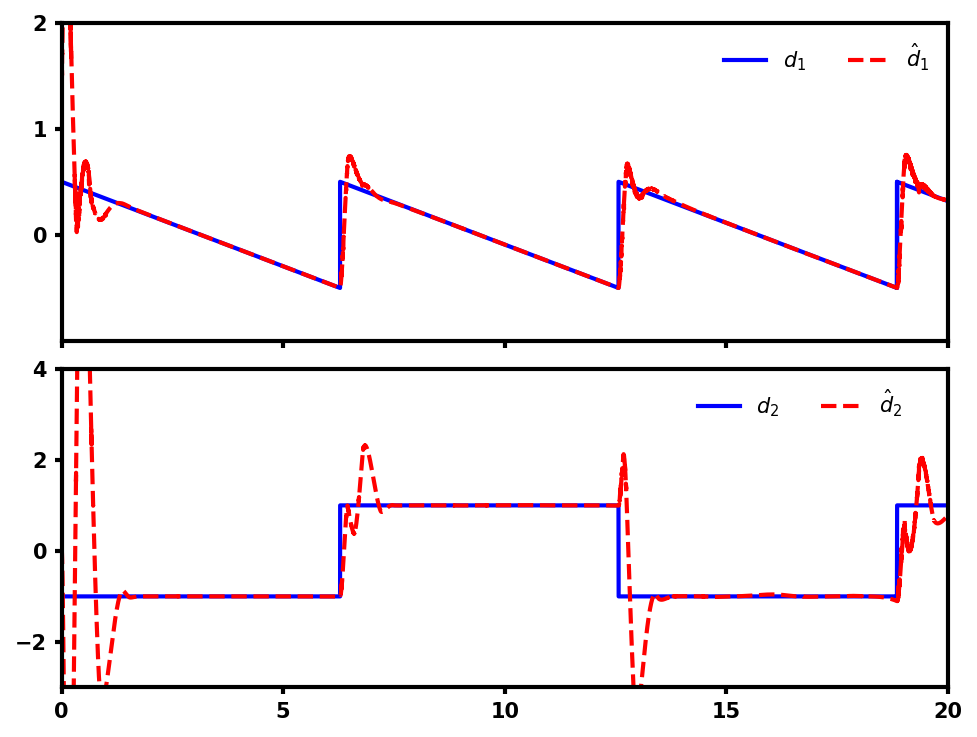

In [190]:
def plot_uios(dist_t, dist_d, dist_d_hat):

    fig, axs = plt.subplots(2, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [-1, 2],
        [-3, 4],
    ]

    for i in range(len(axs)):

        axs[i].plot(dist_t, dist_d[:, i], 'b', label=f'$d_{i+1}$', linewidth=2)
        axs[i].plot(dist_t, dist_d_hat[:, i], 'r--', label=f'$\hat{{d}}_{i+1}$', linewidth=2)
        axs[i].set_ylim(ylims[i])
        axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(1, 1))
        
        axs[i].set_xticks(np.linspace(0, 20, 5))
        
        if i == 0:
            axs[i].set_yticks([0, 1, 2])
        elif i == 1:
            axs[i].set_yticks([-2, 0, 2, 4])
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.97, 1))

        for tick in axs[i].get_xticklabels():
            tick.set_fontweight('bold')
        for tick in axs[i].get_yticklabels():
            tick.set_fontweight('bold')
        for spine in axs[i].spines.values():
            spine.set_linewidth(2)  # Change the value as needed
        axs[i].tick_params(axis='both', width=2)  # Adjust width and length
        
    plt.xlim([0, time])
    plt.savefig(f"figures/disturbances.png")
    plt.show()

plot_uios(dist_t, dist_d, dist_d_hat)

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
C:\Users\luiza\AppData\Local\Temp\ipykernel_19984\3936837996.py:15: SyntaxWarning: invalid escape sequence '\h'
  axs[i].plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$', linewidth=2)


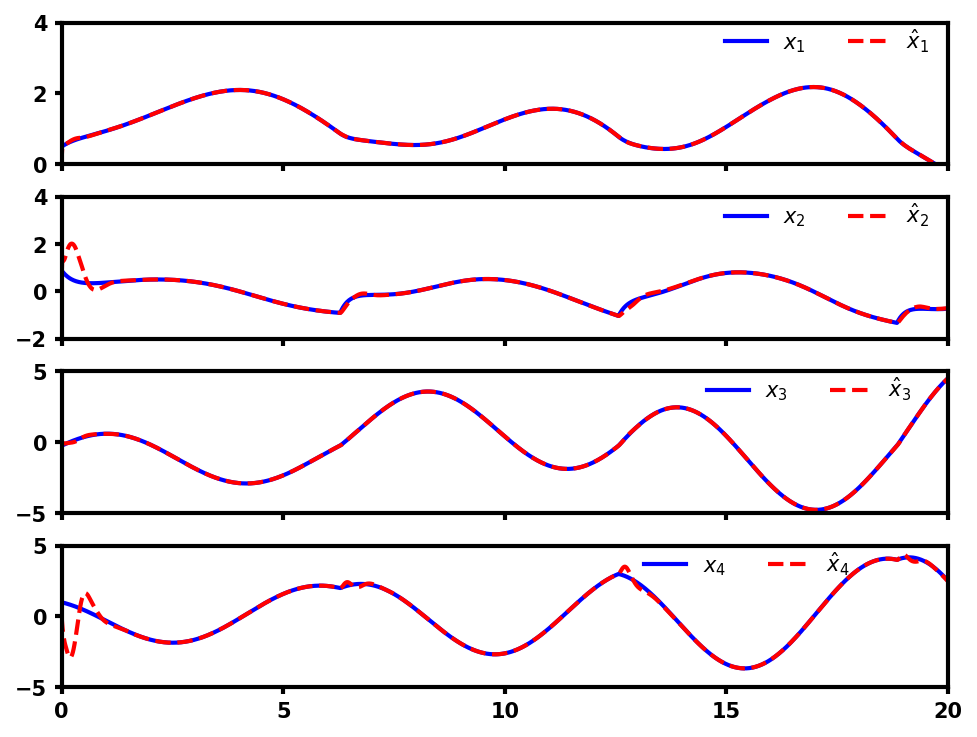

In [191]:
def plot_graph(x, nx):

    fig, axs = plt.subplots(nx, sharex=True, dpi=150, constrained_layout=True)

    ylims = [
        [0, 4],
        [-2, 4],
        [-5, 5],
        [-5, 5]
    ]

    for i in range(len(axs)):

        axs[i].plot(t, x[i], 'b', label=f'$x_{i+1}$', linewidth=2)
        axs[i].plot(t, x[4+i], 'r--', label=f'$\hat{{x}}_{i+1}$', linewidth=2)
        axs[i].set_ylim(ylims[i])
        axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(1, 1.1))

        if i == 2:
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.98, 1.1))
        elif i == 3:
            axs[i].legend(ncols=2, frameon=False, loc='upper right', bbox_to_anchor=(.91, 1.1))
        
        axs[i].set_xticks(np.linspace(0, 20, 5))

        for tick in axs[i].get_xticklabels():
            tick.set_fontweight('bold')
        for tick in axs[i].get_yticklabels():
            tick.set_fontweight('bold')
        for spine in axs[i].spines.values():
            spine.set_linewidth(2)  # Change the value as needed
        axs[i].tick_params(axis='both', width=2)  # Adjust width and length
        

        
    plt.xlim([0, time])
    plt.savefig(f"figures/states.png")
    plt.show()

plot_graph(x, 4)
    